# Procesador de archivos  `postprocesing\u` OpenFOAM V12.00
----------------------------------------------------------
Alumno: Omar Ulises Robles Pereyra

Catedrático: Dr. Gabriel Ruiz Martínez

**Subcoordinación de Posgrado y Educación Continua.**

![Imagen](IMTA_Logo.jpg)

[Instituto Mexicano de Tecnología del Agua](https://www.gob.mx/imta).

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import re

In [3]:
total_probes = 7
data_start = total_probes 
# Carga de archivo postproceso
file = 'U_test.txt'
#file = 'U_test_long.txt'
print(file)

U_test.txt


In [4]:
# Leer el archivo, saltando las líneas de información  de los probes
df   = pd.read_csv(file, skiprows= data_start, sep=r'\s+',comment='#',header=None)
print(df)

             0              1         2                3              4   \
0      0.000000         (0.535  0.000000               0)         (0.535   
1      0.000120   (0.096050696  0.021364   1.4219033e-09)    (0.40619232   
2      0.000264  (-0.093188847  0.030927  -3.4378311e-11)    (0.34911779   
3      0.000437   (0.088590975  0.023989  -1.7601698e-10)     (0.3684291   
4      0.000644    (0.19792166  0.019028  -5.6207361e-10)    (0.38480497   
...         ...            ...       ...              ...            ...   
6366   9.995238   (-0.01183332  0.434502      0.33317144)  (-0.016527944   
6367   9.996429  (-0.011939527  0.430022      0.33742517)  (-0.026833146   
6368   9.997619  (-0.012243417  0.425208       0.3414028)  (-0.038195818   
6369   9.998810   (-0.01277287  0.419990      0.34506775)  (-0.050378847   
6370  10.000000  (-0.013561771  0.414307      0.34838492)  (-0.063064082   

            5                6            7         8                9   ...  \
0     0

In [5]:
df.info()
# Identifica las columnas que contienen los números con paréntesis (ideal)
col_cparentesis = list(range(1, len(df.columns))) 
#print(col_cparentesis)
for col in col_cparentesis:
    df[col] = df[col].apply(lambda x: float(re.sub(r'[()]', '', x)) if isinstance(x, str) else x)
print(df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6371 entries, 0 to 6370
Data columns (total 22 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       6371 non-null   float64
 1   1       6371 non-null   object 
 2   2       6371 non-null   float64
 3   3       6371 non-null   object 
 4   4       6371 non-null   object 
 5   5       6371 non-null   float64
 6   6       6371 non-null   object 
 7   7       6371 non-null   object 
 8   8       6371 non-null   float64
 9   9       6371 non-null   object 
 10  10      6371 non-null   object 
 11  11      6371 non-null   float64
 12  12      6371 non-null   object 
 13  13      6371 non-null   object 
 14  14      6371 non-null   float64
 15  15      6371 non-null   object 
 16  16      6371 non-null   object 
 17  17      6371 non-null   float64
 18  18      6371 non-null   object 
 19  19      6371 non-null   object 
 20  20      6371 non-null   float64
 21  21      6371 non-null   object 
dtype

In [10]:
# Graficar la evolución de la presión en el tiempo de cada probe
time = df[0]
print(time)

0        0.000000
1        0.000120
2        0.000264
3        0.000437
4        0.000644
          ...    
6366     9.995238
6367     9.996429
6368     9.997619
6369     9.998810
6370    10.000000
Name: 0, Length: 6371, dtype: float64


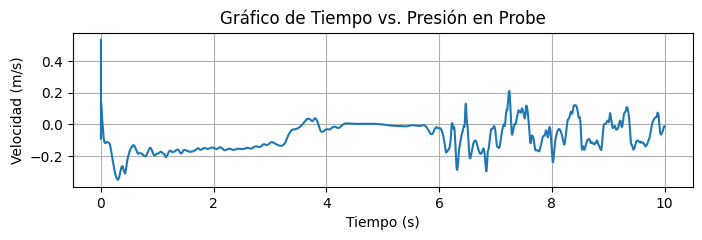

In [16]:
plt.figure(figsize=(8,2))
plt.plot(df.iloc[0:-1,0], df.iloc[0:-1,1])
plt.xlabel('Tiempo (s)')
plt.ylabel('Velocidad (m/s)')  # Asumiendo que la columna 1 es Probe 0
plt.title('Gráfico de Tiempo vs. Velocidad en Probe')
plt.grid(True)
plt.show()